# Food Recommendation System
## Dataset Analysis

### Cilj analize

Cilj ove analize je da detaljno ispitamo dostupne podatke o receptima i interakcijama korisnika sa receptima. 
Analiza će obuhvatiti strukturu podataka, broj recepata i korisnika, distribuciju ocena, nedostajuće vrednosti, 
duplikate i druge karakteristike koje su važne za kasniju izgradnju sistema preporuke.

U ovoj fazi ne treniramo modele. Cilj je da razumemo dataset i na osnovu njegovih karakteristika 
odredimo kako ćemo pripremiti podatke za modele preporuke.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
recipes_path = "../../datasets/RAW_recipes.csv"

recipes = pd.read_csv(recipes_path)

print("Recipes dataset successfully loaded.")

Recipes dataset successfully loaded.


In [3]:
interactions_path = "../../datasets/RAW_interactions.csv"

interactions = pd.read_csv(interactions_path)

print("Interactions dataset successfully loaded.")

Interactions dataset successfully loaded.


In [4]:
recipes.head()

,name,id,minutes,contributor_id,submitted,tags,nutrition,n_steps,steps,description,ingredients,n_ingredients
0,arriba baked winter squash mexican style,137739,55,47892,2005-09-16,"['60-minutes-or-less', 'time-to-make', 'course...","[51.5, 0.0, 13.0, 0.0, 2.0, 0.0, 4.0]",11,"['make a choice and proceed with recipe', 'dep...",autumn is my favorite time of year to cook! th...,"['winter squash', 'mexican seasoning', 'mixed ...",7
1,a bit different breakfast pizza,31490,30,26278,2002-06-17,"['30-minutes-or-less', 'time-to-make', 'course...","[173.4, 18.0, 0.0, 17.0, 22.0, 35.0, 1.0]",9,"['preheat oven to 425 degrees f', 'press dough...",this recipe calls for the crust to be prebaked...,"['prepared pizza crust', 'sausage patty', 'egg...",6
2,all in the kitchen chili,112140,130,196586,2005-02-25,"['time-to-make', 'course', 'preparation', 'mai...","[269.8, 22.0, 32.0, 48.0, 39.0, 27.0, 5.0]",6,"['brown ground beef in large pot', 'add choppe...",this modified version of 'mom's' chili was a h...,"['ground beef', 'yellow onions', 'diced tomato...",13
3,alouette potatoes,59389,45,68585,2003-04-14,"['60-minutes-or-less', 'time-to-make', 'course...","[368.1, 17.0, 10.0, 2.0, 14.0, 8.0, 20.0]",11,['place potatoes in a large pot of lightly sal...,"this is a super easy, great tasting, make ahea...","['spreadable cheese with garlic and herbs', 'n...",11
4,amish tomato ketchup for canning,44061,190,41706,2002-10-25,"['weeknight', 'time-to-make', 'course', 'main-...","[352.9, 1.0, 337.0, 23.0, 3.0, 0.0, 28.0]",5,['mix all ingredients& boil for 2 1 / 2 hours ...,my dh's amish mother raised him on this recipe...,"['tomato juice', 'apple cider vinegar', 'sugar...",8


In [5]:
interactions.head()

,user_id,recipe_id,date,rating,review
0,38094,40893,2003-02-17,4,Great with a salad. Cooked on top of stove for...
1,1293707,40893,2011-12-21,5,"So simple, so delicious! Great for chilly fall..."
2,8937,44394,2002-12-01,4,This worked very well and is EASY. I used not...
3,126440,85009,2010-02-27,5,I made the Mexican topping and took it to bunk...
4,57222,85009,2011-10-01,5,"Made the cheddar bacon topping, adding a sprin..."


In [6]:
print("Recipes shape:", recipes.shape)
print("Interactions shape:", interactions.shape)

Recipes shape: (231637, 12)
Interactions shape: (1132367, 5)


In [7]:
print("Number of recipes:", recipes["id"].nunique())
print("Number of users:", interactions["user_id"].nunique())
print("Number of ratings:", len(interactions))

Number of recipes: 231637
Number of users: 226570
Number of ratings: 1132367


In [8]:
recipes.info()

<class 'pandas.DataFrame'>
RangeIndex: 231637 entries, 0 to 231636
Data columns (total 12 columns):
 #   Column          Non-Null Count   Dtype
---  ------          --------------   -----
 0   name            231636 non-null  str  
 1   id              231637 non-null  int64
 2   minutes         231637 non-null  int64
 3   contributor_id  231637 non-null  int64
 4   submitted       231637 non-null  str  
 5   tags            231637 non-null  str  
 6   nutrition       231637 non-null  str  
 7   n_steps         231637 non-null  int64
 8   steps           231637 non-null  str  
 9   description     226658 non-null  str  
 10  ingredients     231637 non-null  str  
 11  n_ingredients   231637 non-null  int64
dtypes: int64(5), str(7)
memory usage: 21.2 MB


In [9]:
interactions.info()

<class 'pandas.DataFrame'>
RangeIndex: 1132367 entries, 0 to 1132366
Data columns (total 5 columns):
 #   Column     Non-Null Count    Dtype
---  ------     --------------    -----
 0   user_id    1132367 non-null  int64
 1   recipe_id  1132367 non-null  int64
 2   date       1132367 non-null  str  
 3   rating     1132367 non-null  int64
 4   review     1132198 non-null  str  
dtypes: int64(3), str(2)
memory usage: 43.2 MB


In [10]:
recipes_missing = recipes.isnull().sum()

print("Missing values in recipes:")
print(recipes_missing)

Missing values in recipes:
name                 1
id                   0
minutes              0
contributor_id       0
submitted            0
tags                 0
nutrition            0
n_steps              0
steps                0
description       4979
ingredients          0
n_ingredients        0
dtype: int64


In [11]:
interactions_missing = interactions.isnull().sum()

print("Missing values in interactions:")
print(interactions_missing)

Missing values in interactions:
user_id        0
recipe_id      0
date           0
rating         0
review       169
dtype: int64


In [12]:
recipes_missing_summary = pd.DataFrame({
    "missing_count": recipes.isnull().sum(),
    "missing_percentage": recipes.isnull().mean() * 100
})

recipes_missing_summary

,missing_count,missing_percentage
name,1,0.000432
id,0,0.000000
minutes,0,0.000000
contributor_id,0,0.000000
submitted,0,0.000000
tags,0,0.000000
nutrition,0,0.000000
n_steps,0,0.000000
steps,0,0.000000
description,4979,2.149484


In [13]:
interactions_missing_summary = pd.DataFrame({
    "missing_count": interactions.isnull().sum(),
    "missing_percentage": interactions.isnull().mean() * 100
})

interactions_missing_summary

,missing_count,missing_percentage
user_id,0,0.000000
recipe_id,0,0.000000
date,0,0.000000
rating,0,0.000000
review,169,0.014924


In [14]:
print("Duplicate rows in recipes:", recipes.duplicated().sum())
print("Duplicate rows in interactions:", interactions.duplicated().sum())

Duplicate rows in recipes: 0
Duplicate rows in interactions: 0


In [15]:
user_recipe_counts = (
    interactions
    .groupby(["user_id", "recipe_id"])
    .size()
    .reset_index(name="interaction_count")
)

print(
    "Number of user-recipe pairs with more than one interaction:",
    (user_recipe_counts["interaction_count"] > 1).sum()
)

Number of user-recipe pairs with more than one interaction: 0


In [16]:
print(
    "Maximum interactions for a single user-recipe pair:",
    user_recipe_counts["interaction_count"].max()
)   

Maximum interactions for a single user-recipe pair: 1


In [17]:
rating_counts = interactions["rating"].value_counts().sort_index()

rating_counts

rating
0     60847
1     12818
2     14123
3     40855
4    187360
5    816364
Name: count, dtype: int64

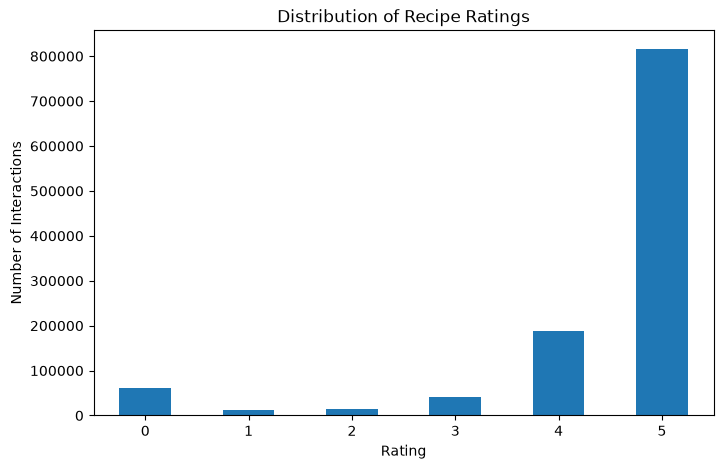

In [18]:
plt.figure(figsize=(8, 5))

rating_counts.plot(kind="bar")

plt.title("Distribution of Recipe Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Interactions")
plt.xticks(rotation=0)

plt.show()

In [19]:
rating_percentages = (
        interactions["rating"]
        .value_counts(normalize=True)
        .sort_index()
        * 100
)

rating_percentages

rating
0     5.373435
1     1.131965
2     1.247210
3     3.607929
4    16.545872
5    72.093588
Name: proportion, dtype: float64

In [20]:
num_users = interactions["user_id"].nunique()
num_recipes = recipes["id"].nunique()
num_interactions = len(interactions)

total_possible_interactions = num_users * num_recipes

sparsity = 1 - (num_interactions / total_possible_interactions)

print("Users:", num_users)
print("Recipes:", num_recipes)
print("Observed interactions:", num_interactions)
print("Possible interactions:", total_possible_interactions)
print("Sparsity:", sparsity)
print("Sparsity (%):", sparsity * 100)

Users: 226570
Recipes: 231637
Observed interactions: 1132367
Possible interactions: 52481995090
Sparsity: 0.9999784237051572
Sparsity (%): 99.99784237051573


In [21]:
user_activity = interactions.groupby("user_id").size()

print("Average interactions per user:", user_activity.mean())
print("Median interactions per user:", user_activity.median())
print("Minimum interactions per user:", user_activity.min())
print("Maximum interactions per user:", user_activity.max())

Average interactions per user: 4.997868208500684
Median interactions per user: 1.0
Minimum interactions per user: 1
Maximum interactions per user: 7671


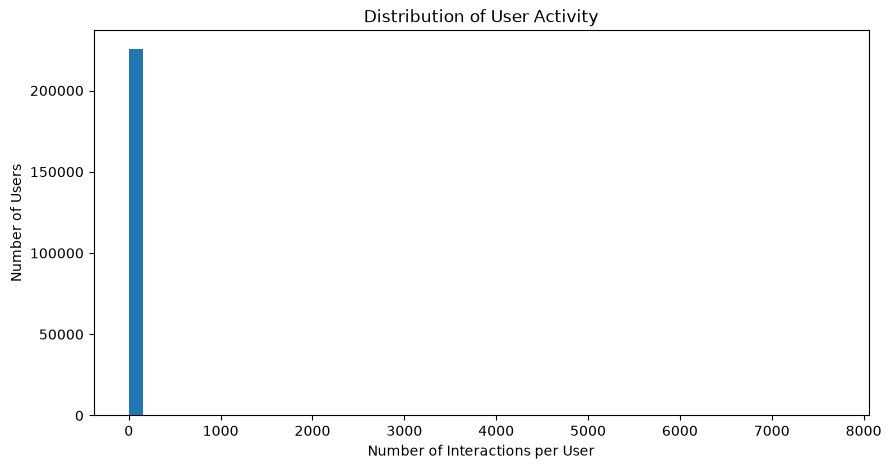

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(user_activity, bins=50)

plt.title("Distribution of User Activity")
plt.xlabel("Number of Interactions per User")
plt.ylabel("Number of Users")

plt.show()

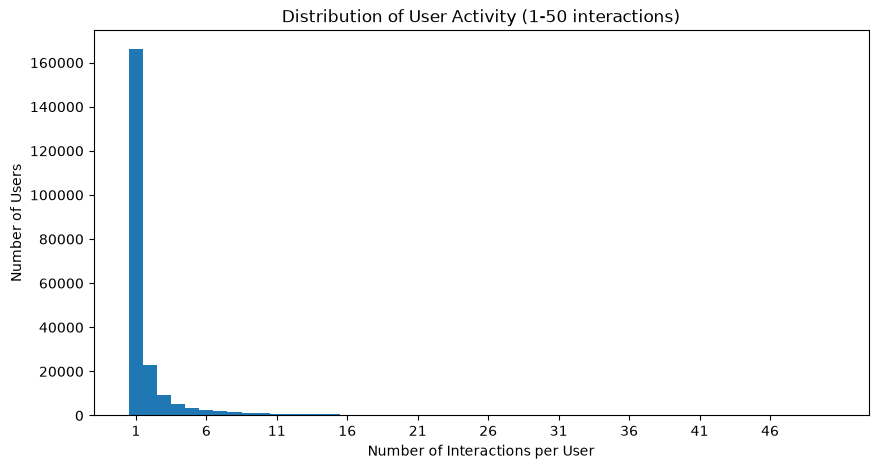

In [25]:
user_activity_50 = user_activity[user_activity <= 50]

plt.figure(figsize=(10, 5))

plt.hist(
    user_activity_50,
    bins=50,
    range=(0.5, 50.5)
)

plt.title("Distribution of User Activity (1-50 interactions)")
plt.xlabel("Number of Interactions per User")
plt.ylabel("Number of Users")

plt.xticks(range(1, 51, 5))

plt.show()

In [23]:
recipe_popularity = interactions.groupby("recipe_id").size()

print("Average interactions per recipe:", recipe_popularity.mean())
print("Median interactions per recipe:", recipe_popularity.median())
print("Minimum interactions per recipe:", recipe_popularity.min())
print("Maximum interactions per recipe:", recipe_popularity.max())

Average interactions per recipe: 4.888541122532238
Median interactions per recipe: 2.0
Minimum interactions per recipe: 1
Maximum interactions per recipe: 1613


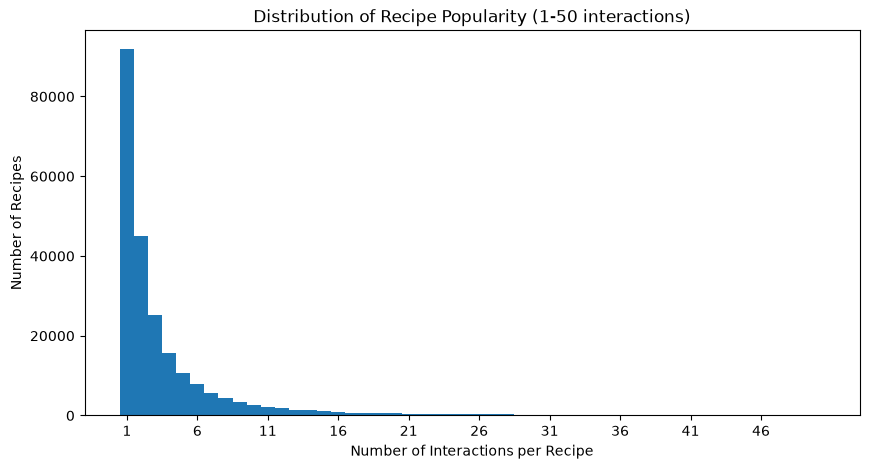

In [26]:
recipe_popularity_50 = recipe_popularity[recipe_popularity <= 50]

plt.figure(figsize=(10, 5))

plt.hist(
    recipe_popularity_50,
    bins=50,
    range=(0.5, 50.5)
)

plt.title("Distribution of Recipe Popularity (1-50 interactions)")
plt.xlabel("Number of Interactions per Recipe")
plt.ylabel("Number of Recipes")

plt.xticks(range(1, 51, 5))

plt.show()

In [27]:
top_recipes = (
    recipe_popularity
    .sort_values(ascending=False)
    .head(10)
)

top_recipes

recipe_id
2886     1613
27208    1601
89204    1579
39087    1448
67256    1322
54257    1305
22782    1234
32204    1220
69173     997
68955     904
dtype: int64

In [28]:
top_recipes_info = (
    top_recipes
    .rename("interaction_count")
    .reset_index()
    .merge(
        recipes[["id", "name"]],
        left_on="recipe_id",
        right_on="id",
        how="left"
    )
    [["recipe_id", "name", "interaction_count"]]
)

top_recipes_info

,recipe_id,name,interaction_count
0,2886,best banana bread,1613
1,27208,to die for crock pot roast,1601
2,89204,crock pot chicken with black beans cream cheese,1579
3,39087,creamy cajun chicken pasta,1448
4,67256,best ever banana cake with cream cheese frosting,1322
5,54257,yes virginia there is a great meatloaf,1305
6,22782,jo mama s world famous spaghetti,1234
7,32204,whatever floats your boat brownies,1220
8,69173,kittencal s italian melt in your mouth meatballs,997
9,68955,japanese mum s chicken,904


In [29]:
explicit_ratings = interactions[interactions["rating"] > 0].copy()

print("Original interactions:", len(interactions))
print("Explicit ratings:", len(explicit_ratings))
print("Removed rating=0:", len(interactions) - len(explicit_ratings))

Original interactions: 1132367
Explicit ratings: 1071520
Removed rating=0: 60847


In [30]:
user_counts = explicit_ratings.groupby("user_id").size()

thresholds = [1, 2, 3, 5, 10]

for threshold in thresholds:
    users_remaining = (user_counts >= threshold).sum()
    interactions_remaining = user_counts[user_counts >= threshold].sum()

    print(
        f"Minimum {threshold}: "
        f"{users_remaining} users, "
        f"{interactions_remaining} interactions"
    )

Minimum 1: 196098 users, 1071520 interactions
Minimum 2: 55780 users, 931202 interactions
Minimum 3: 35464 users, 890570 interactions
Minimum 5: 22018 users, 845346 interactions
Minimum 10: 12035 users, 780643 interactions


In [31]:
recipe_counts = explicit_ratings.groupby("recipe_id").size()

thresholds = [1, 2, 3, 5, 10]

for threshold in thresholds:
    recipes_remaining = (recipe_counts >= threshold).sum()
    interactions_remaining = recipe_counts[recipe_counts >= threshold].sum()

    print(
        f"Minimum {threshold}: "
        f"{recipes_remaining} recipes, "
        f"{interactions_remaining} interactions"
    )
    

Minimum 1: 226590 recipes, 1071520 interactions
Minimum 2: 134892 recipes, 979822 interactions
Minimum 3: 90437 recipes, 890912 interactions
Minimum 5: 50978 recipes, 757481 interactions
Minimum 10: 20060 recipes, 558498 interactions


In [32]:
MIN_USER_RATINGS = 5
MIN_RECIPE_RATINGS = 5

filtered_ratings = explicit_ratings.copy()

while True:
    user_counts = filtered_ratings.groupby("user_id").size()
    recipe_counts = filtered_ratings.groupby("recipe_id").size()

    valid_users = user_counts[user_counts >= MIN_USER_RATINGS].index
    valid_recipes = recipe_counts[recipe_counts >= MIN_RECIPE_RATINGS].index

    new_filtered_ratings = filtered_ratings[
        filtered_ratings["user_id"].isin(valid_users)
        & filtered_ratings["recipe_id"].isin(valid_recipes)
        ].copy()

    if len(new_filtered_ratings) == len(filtered_ratings):
        break

    filtered_ratings = new_filtered_ratings

print("Filtered interactions:", len(filtered_ratings))
print("Filtered users:", filtered_ratings["user_id"].nunique())
print("Filtered recipes:", filtered_ratings["recipe_id"].nunique())

Filtered interactions: 535047
Filtered users: 17034
Filtered recipes: 40027


In [33]:
from sklearn.model_selection import train_test_split

train_ratings, test_ratings = train_test_split(
    filtered_ratings,
    test_size=0.20,
    random_state=42
)

print("Train interactions:", len(train_ratings))
print("Test interactions:", len(test_ratings))
print("Total interactions:", len(train_ratings) + len(test_ratings))

Train interactions: 428037
Test interactions: 107010
Total interactions: 535047


In [34]:
train_users = set(train_ratings["user_id"])
test_users = set(test_ratings["user_id"])

train_recipes = set(train_ratings["recipe_id"])
test_recipes = set(test_ratings["recipe_id"])

cold_start_users = test_users - train_users
cold_start_recipes = test_recipes - train_recipes

print("Cold-start users in test:", len(cold_start_users))
print("Cold-start recipes in test:", len(cold_start_recipes))

Cold-start users in test: 2
Cold-start recipes in test: 4


In [35]:
from sklearn.model_selection import train_test_split

train_ratings, test_ratings = train_test_split(
    filtered_ratings,
    test_size=0.20,
    random_state=42
)

# Provera cold-start korisnika i recepata
while True:
    train_users = set(train_ratings["user_id"])
    train_recipes = set(train_ratings["recipe_id"])

    test_users = set(test_ratings["user_id"])
    test_recipes = set(test_ratings["recipe_id"])

    cold_start_users = test_users - train_users
    cold_start_recipes = test_recipes - train_recipes

    if len(cold_start_users) == 0 and len(cold_start_recipes) == 0:
        break

    cold_start_mask = (
            test_ratings["user_id"].isin(cold_start_users)
            | test_ratings["recipe_id"].isin(cold_start_recipes)
    )

    train_ratings = pd.concat(
        [train_ratings, test_ratings[cold_start_mask]],
        ignore_index=True
    )

    test_ratings = test_ratings[~cold_start_mask].copy()

print("Train interactions:", len(train_ratings))
print("Test interactions:", len(test_ratings))

print("Cold-start users:", len(cold_start_users))
print("Cold-start recipes:", len(cold_start_recipes))

Train interactions: 428067
Test interactions: 106980
Cold-start users: 0
Cold-start recipes: 0


In [36]:
import os

os.makedirs("../datasets/processed", exist_ok=True)

print("Processed folder is ready.")

Processed folder is ready.


In [37]:
filtered_ratings.to_csv(
    "../datasets/processed/filtered_ratings.csv",
    index=False
)

train_ratings.to_csv(
    "../datasets/processed/train_ratings.csv",
    index=False
)

test_ratings.to_csv(
    "../datasets/processed/test_ratings.csv",
    index=False
)

print("Processed datasets saved successfully.")

Processed datasets saved successfully.
